<h1>Analiza ilości oraz wartości grzybów sprzedanych w Polsce w latach 2016-2020</h1>

Badanie dotyczy analizy ilości i wartości grzybów oraz owoców leśnych w Polsce w latach 2016-2020.
Celem jest określenie różnic między województwami oraz zmian w czasie w poszczególnych regionach, a także identyfikacja czynników wpływających na te zróżnicowanie.

Wykorzystywane dane pochodzą z Banku Danych Lokalnych GUS.

<h2>Zmienne użyte do analizy to:</h2>
"Dewastacja" - grunty zdewastowane i zdegradowane wymagające rekultywacji [ha]<br>
"Pozary" - pożary lasów w ciągu roku [ilość]<br>
"Za_gaz" - zanieczyszczenie powietrza (w formie gazowej) [mikrogram/m3]<br>
"Za-pyl" - zanieczyszczenie powietrza (w formie pyłu) [t/r]<br>
"Zatrudnienie" - procent zatrudnienia osób w stosunku do całego województwa [%]<br>
"Ilosc" - ilość sprzedanych grzybów w ciągu roku wynikająca z oficjalnych transakcji dokonanych przez podmioty gospodarcze [t]<br>
"Wartosc" - wartość sprzedanych grzybów w ciągu roku wynikająca z oficjalnych transakcji dokonanych przez podmioty gospodarcze [tys. zł]<br>
"P_lasy" - powierzchnia lasów [ha]<br>
"P_lasy_ch" - powierzchnia lasów chronionych [ha]

In [ ]:
!git clone https://github.com/AleksandraJuchniewicz/Analiza-danych.git

In [ ]:
%cd Analiza-danych
!ls

In [4]:
import pandas as pd

df_d = pd.read_csv("bdl_data_dewastacja_.csv")
df_poz=pd.read_csv("bdl_data_pozar_.csv")
df_gaz=pd.read_csv("bdl_data_Zangaz_.csv")
df_pyl=pd.read_csv("bdl_data_Zanpyl_.csv")
df_zat=pd.read_csv("bdl_data_zatrudnienie_.csv")
df_il=pd.read_csv("bdl_datailosc_2024_.csv")
df_war=pd.read_csv("bdl_datawartosc_2024_.csv")
df_las=pd.read_csv("bdl_powlas_2024_.csv")
df_lasch=pd.read_csv("bdl_powlaschro_2024_.csv")

dfs = [df_d, df_poz, df_gaz, df_pyl, df_zat, df_il, df_war, df_las, df_lasch]
new_names = [
    "Dewastacja",
    "Pozary",
    "Za_gaz",
    "Za-pyl",
    "Zatrudnienie",
    "Ilosc",
    "Wartosc",
    "P_lasy",
    "P_lasy_ch"
]
for df, new_name in zip(dfs, new_names):
    df.rename(columns={"Value": new_name}, inplace=True)
for i, df in enumerate(dfs, start=1):
    print(f"df{i}:", df.columns.tolist())
for i in range(len(dfs)):
    dfs[i] = dfs[i].loc[
        (dfs[i]["Year"] >= 2016) &
        (dfs[i]["Year"] <= 2020)
    ].copy()

for i, df in enumerate(dfs, start=1):
    print(f"df{i}: {sorted(df['Year'].unique())}")
from functools import reduce

df_all = reduce(
    lambda left, right: left.merge(
        right,
        on=["Region", "Year"],
        how="inner"
    ),
    dfs
)

print(df_all.shape)
print(df_all.head())

df1: ['Region', 'Year', 'Dewastacja']
df2: ['Region', 'Year', 'Pozary']
df3: ['Region', 'Year', 'Za_gaz']
df4: ['Region', 'Year', 'Za-pyl']
df5: ['Region', 'Year', 'Zatrudnienie']
df6: ['Region', 'Year', 'Ilosc']
df7: ['Region', 'Year', 'Wartosc']
df8: ['Region', 'Year', 'P_lasy']
df9: ['Region', 'Year', 'P_lasy_ch']
df1: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df2: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df3: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df4: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df5: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df6: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df7: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df8: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(

<h1> Wyniki analiz </h1>

<h2>Analizy braków i outlierów</h2>



In [5]:
#braki
df_all.isna().sum()
#duikaty
df_all.duplicated(["Region", "Year"]).sum()


np.int64(0)

Nie stwierdzono żadnych braków w analizowanych danych. Obserwacje nie są zdublowane. Zbiór danych jest gotowy do dalszej analizy.

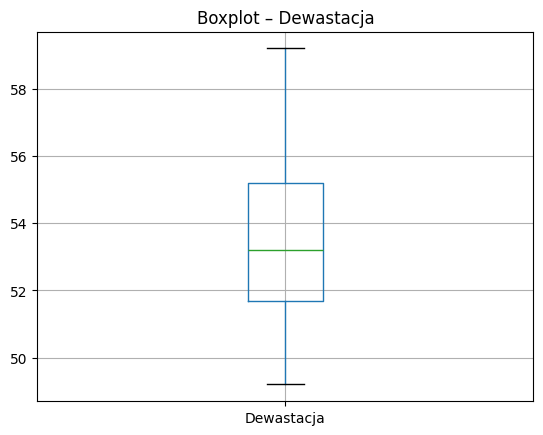

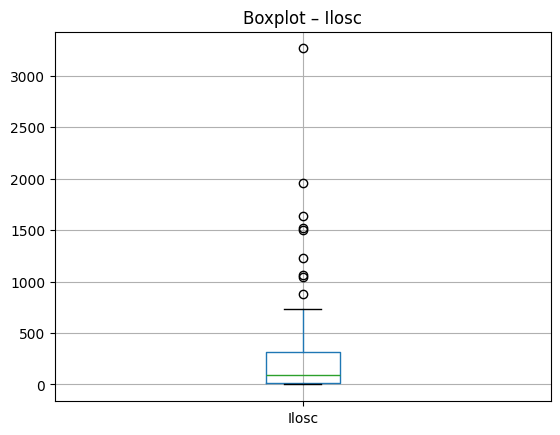

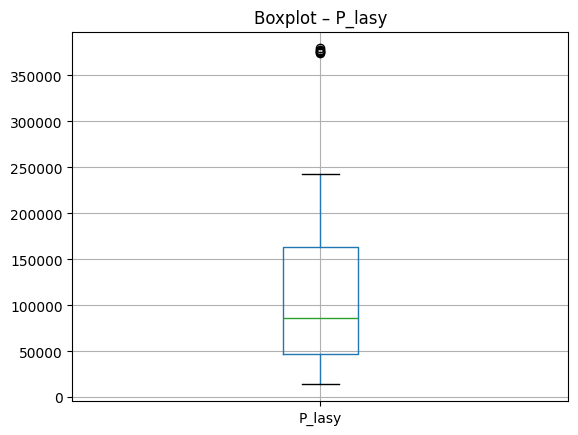

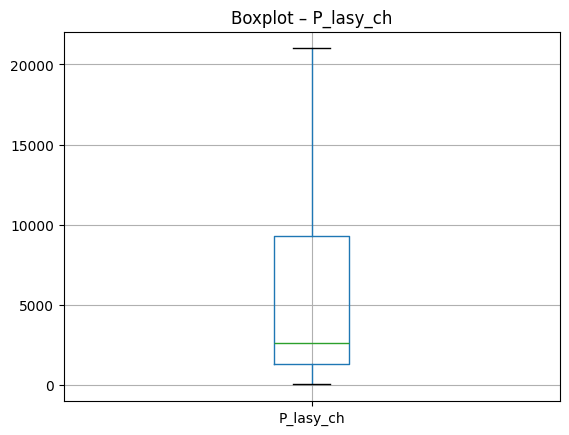

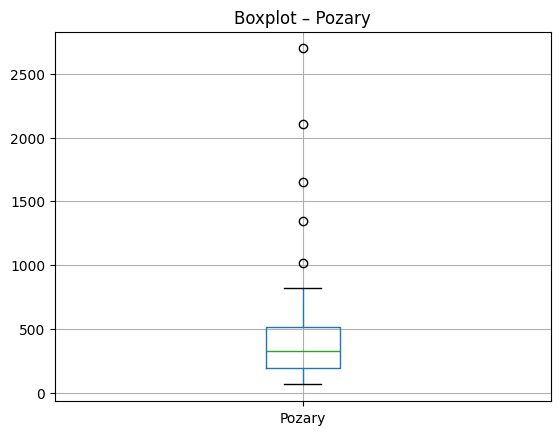

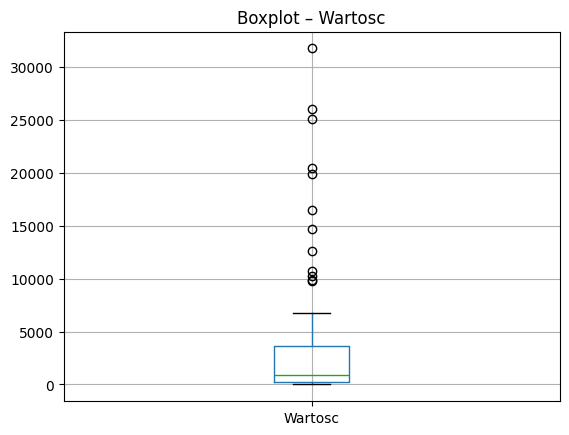

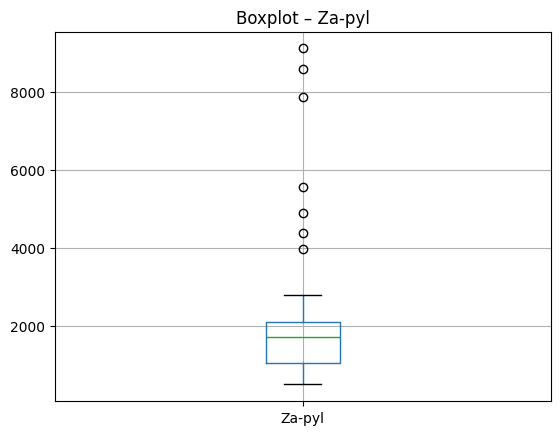

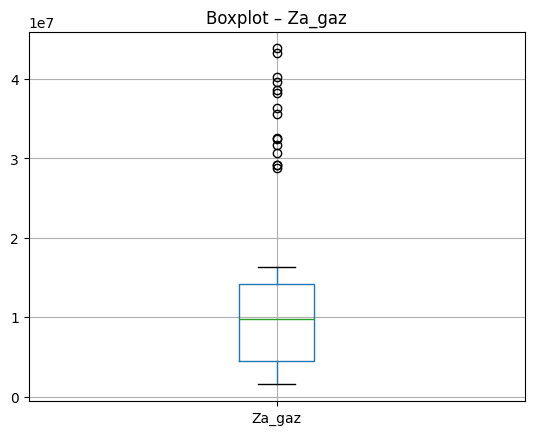

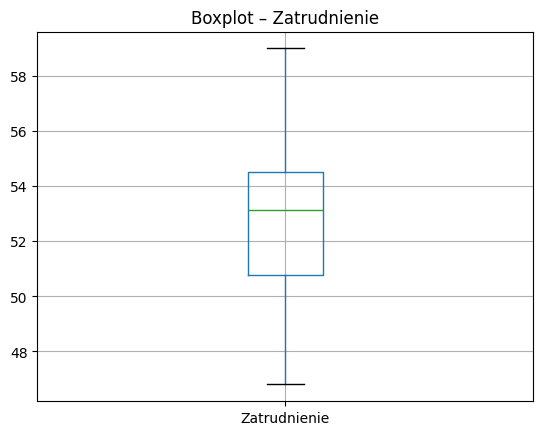

In [6]:
cols_to_plot = df_all.columns.difference(["Region", "Year"])

import matplotlib.pyplot as plt

for col in cols_to_plot:
    plt.figure()
    df_all.boxplot(column=col)
    plt.title(f"Boxplot – {col}")
    plt.show()

In [7]:
def iqr_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)].copy()
    outliers["Zmienna"] = col
    outliers["Dolna_granica"] = lower
    outliers["Gorna_granica"] = upper

    return outliers


In [8]:
outlier_list = []

for col in cols_to_plot:
    out = iqr_outliers(df_all, col)
    outlier_list.append(out)

outliers_df = pd.concat(outlier_list, ignore_index=True)

outliers_df = outliers_df[
    ["Zmienna", "Region", "Year", col]
]
outliers_df.groupby("Zmienna").size()
print(outliers_df)


    Zmienna               Region  Year  Zatrudnienie
0     Ilosc             LUBUSKIE  2017          53.7
1     Ilosc             LUBUSKIE  2019          54.5
2     Ilosc        WIELKOPOLSKIE  2016          55.2
3     Ilosc        WIELKOPOLSKIE  2017          57.2
4     Ilosc        WIELKOPOLSKIE  2018          57.7
5     Ilosc        WIELKOPOLSKIE  2019          57.5
6     Ilosc            POMORSKIE  2016          54.6
7     Ilosc            POMORSKIE  2017          56.0
8     Ilosc            POMORSKIE  2019          58.1
9    P_lasy          MAZOWIECKIE  2016          56.2
10   P_lasy          MAZOWIECKIE  2017          57.2
11   P_lasy          MAZOWIECKIE  2018          58.4
12   P_lasy          MAZOWIECKIE  2019          59.0
13   P_lasy          MAZOWIECKIE  2020          58.6
14   Pozary          MAZOWIECKIE  2016          56.2
15   Pozary          MAZOWIECKIE  2017          57.2
16   Pozary          MAZOWIECKIE  2018          58.4
17   Pozary          MAZOWIECKIE  2019        

Na wykresach pudełkowych oraz w analizie IQR zaobserwowano liczne obserwacje, zaznaczone jako wartości odstające. Należy jednak wziąć pod uwagę charakter badanych zmiennych. Są to obserwacje pokazujące m.in. powierzchnię, wartość lub częstość danego zjawiska. Dla takich danych duże wartości nie są anomalią, którą należy wykluczyć z dalszej analizy. Jest to wtedy konsekwencja skali zjawiska (zależność na przykład od wielkości powierzchni regionu lub innych jego uwarunkowań). Boxploty nie uwzględniają zatem charakteru zmiennej, przez co identyfikują jako outliery obserwacje odstające również wtedy, gdy są one dla danej zmiennej naturalne.   

<h2>Statystyki opisowe</h2>


In [9]:
df_num=df_all.drop(columns=['Region', 'Year'])
df_all_std=(df_num-df_num.mean())/df_num.std()

In [10]:
summary=df_num.describe().T

In [11]:
print(df_all_std)

    Dewastacja    Pozary    Za_gaz    Za-pyl  Zatrudnienie     Ilosc  \
0     0.431116 -0.784158 -0.230213  0.075630     -0.901115 -0.514918   
1     0.125901 -0.738746 -0.156790  0.069387     -0.585550 -0.526069   
2    -0.310120 -0.451936 -0.194398 -0.065454     -0.234921 -0.539079   
3     0.474718 -0.561880 -0.320107 -0.194052      0.185833 -0.505625   
4     1.521168 -0.595341 -0.488715 -0.535525      0.185833 -0.522352   
..         ...       ...       ...       ...           ...       ...   
75    1.521168  2.196281  1.351867  0.529470      1.132530 -0.100456   
76    1.695576  1.412332  1.381838  0.500129      1.483159  0.031503   
77    2.000790  4.027087  1.593547  0.397126      1.903913 -0.364373   
78    2.524015  5.434848  1.670592  0.299116      2.114290  0.174613   
79    2.000790  2.927647  1.508446  0.152414      1.974039 -0.185950   

     Wartosc    P_lasy  P_lasy_ch  
0  -0.509705  0.884550   2.173298  
1  -0.551305  0.883905   2.185269  
2  -0.565926  0.876524   2.

In [12]:
df_all_std.shape

(80, 9)

In [13]:
summary['skew']=df_num.skew()
summary['kurtosis']=df_num.kurtosis()

In [14]:
summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Dewastacja,80.0,5.341125e+01,2.293469e+00,49.20,51.675,53.200,5.520000e+01,59.20,0.330181,-0.473597
Pozary,80.0,4.250875e+02,4.183949e+02,63.00,194.750,325.000,5.152500e+02,2699.00,3.344084,13.877614
Za_gaz,80.0,1.278226e+07,1.182737e+07,1531405.00,4533884.250,9755750.000,1.413255e+07,43835731.00,1.325411,0.609765
Za-pyl,80.0,1.945850e+03,1.601886e+03,503.00,1048.000,1713.000,2.093250e+03,9113.00,2.932597,9.701238
Zatrudnienie,80.0,5.297000e+01,2.852021e+00,46.80,50.775,53.150,5.452500e+01,59.00,0.101028,-0.578443
Ilosc,80.0,2.990500e+02,5.380471e+02,0.00,18.000,92.500,3.122500e+02,3264.00,3.148605,12.252100
Wartosc,80.0,3.805298e+03,6.545551e+03,0.00,224.750,863.250,3.674525e+03,31711.90,2.506930,6.230321
P_lasy,80.0,1.168589e+05,9.641207e+04,13991.00,47077.070,86609.380,1.636227e+05,379481.59,1.214854,1.054494
P_lasy_ch,80.0,5.577767e+03,5.735863e+03,51.15,1328.385,2635.355,9.300225e+03,21005.56,1.088373,-0.038473


Dla wszystkich badanych zmiennych liczebność próby wynosiła 80 obserwacji. Średnia arytmetyczna wskazuje bardzo zróżnicowane wartości, w zależności od charakteru zmiennej. W przypadku zmiennych asymetrycznych, średnia jest znacząco zawyżona przez obserwacje ekstremalne. Największe zróżnicowanie obserwacji zanotowano dla zmiennej ukazującej zanieczyszczenia gazem. Sugeruje to niestabilność tego zjawiska, a także jego zróżnicowanie regionalne. Z kolei mniejsze odchylenia od średniej zaobserwowano dla zmiennych Zatrudnienie oraz Dewastacja, co pokazuje ich niski poziom zmienności. Wartości minimalne dla zmiennych Ilość oraz Wartość wyniosły 0. Pokazuje to, że w niektórych województwach, a także poszczególnych latach, nie odnotowano wartości skupu. Pierwszy kwartyl zmiennej Pożary wyniósł 194,75, co oznacza, że 25% obserwacji nie przekroczyło tej wartości zmiennej. Warto zauważyć, że średnia dla tej zmiennej była ponad dwukrotnie wyższa. Z kolei mediana liczby pożarów wyniosła 325. Dla Zatrudnienia oraz Dewastacji mediana i średnia pozostają zbliżone. Trzeci kwartyl dla zmiennej Pożary wyniósł 515,25, natomiast dla Ilości 312,25, co pokazuje, że górne 25% obserwacji przyjmuje znacznie wyższe wartości niż mediana. Wartości maksymalne znacząco przewyższają kwartyl górny w przypadku większości zmiennych, co potwierdza obecność ekstremalnych obserwacji. Dodatnie wartości współczynnika skośności dla wszystkich analizowanych zmiennych oznaczają występowanie rozkładów prawostronnie asymetrycznych. Natomiast zmienne Zatrudnienie oraz Dewastacja wykazują prawie symetryczne rozkłady. Wysokie wartości kurtozy dla zmiennych Pożary i Ilość wskazują na rozkłady o grubych ogonach. Z kolei ujemna kurtoza zmiennych Zatrudnienie oraz Dewastacja sugeruje rozkłady bardziej spłaszczone, zbliżone do normalnych. Przeprowadzona analiza potwierdza istotne zróżnicowanie badanych zmiennych. Zauważyć można występowanie silnej asymetrii, szczególnie w przypadku zmiennych opisujących zdarzenia losowe (Pożary).

In [15]:
df_num.corr()

,Dewastacja,Pozary,Za_gaz,Za-pyl,Zatrudnienie,Ilosc,Wartosc,P_lasy,P_lasy_ch
Dewastacja,1.000000,0.513071,0.296160,-0.084167,0.873585,0.350436,0.313480,0.324774,0.268213
Pozary,0.513071,1.000000,0.441110,0.150779,0.485639,0.015386,0.005979,0.546516,0.320057
Za_gaz,0.296160,0.441110,1.000000,0.660897,0.280072,-0.130682,-0.192189,0.245281,0.256556
Za-pyl,-0.084167,0.150779,0.660897,1.000000,0.004814,0.024965,-0.030714,0.016036,0.351263
Zatrudnienie,0.873585,0.485639,0.280072,0.004814,1.000000,0.461512,0.426802,0.132082,0.120612
Ilosc,0.350436,0.015386,-0.130682,0.024965,0.461512,1.000000,0.971345,-0.144190,-0.123008
Wartosc,0.313480,0.005979,-0.192189,-0.030714,0.426802,0.971345,1.000000,-0.164042,-0.157629
P_lasy,0.324774,0.546516,0.245281,0.016036,0.132082,-0.144190,-0.164042,1.000000,0.630770
P_lasy_ch,0.268213,0.320057,0.256556,0.351263,0.120612,-0.123008,-0.157629,0.630770,1.000000


Analiza korelacji Pearsona pokazuje istotne zróżnicowanie siły oraz kierunku zależności pomiędzy badanymi zmiennymi. Najsilniejszą korelację dodatnią zaobserwowano między zmiennymi Dewastacja i Zatrudnienie (0,874). Sugeruje to, że wzrost poziomu zatrudnienia związany jest ze wzrostem skali dewastacji. Możliwą przyczyną jest wzrost poziomu urbanizacji oraz zwiększanie liczby miejsc pracy, które wiążą się ze wzrostem zatrudnienia. Zmienna Pożary jest dodatnio skorelowana ze zmienną Zatrudnienie oraz Dewastacja, co może sugerować wpływ działalności człowieka na częstość występowania pożarów. Dodatnia zależność pomiędzy zmiennymi związanymi z zanieczyszczeniami związanymi z pyłem i gazem potwierdza jednoczesne występowanie obu tych zanieczyszczeń. Analiza korelacji Pearsona wykazała istnienie kilku silnych bądź umiarkowanych wartości korelacji. Jednakże duża liczba słabych korelacji wskazuje na złożony charakter badanego zjawiska, na który wpływ ma wiele czynników.  

In [16]:
df_num.corr(method='spearman')

,Dewastacja,Pozary,Za_gaz,Za-pyl,Zatrudnienie,Ilosc,Wartosc,P_lasy,P_lasy_ch
Dewastacja,1.000000,0.258869,0.315302,0.103775,0.872304,0.456331,0.416381,0.119702,0.172177
Pozary,0.258869,1.000000,0.360112,0.371274,0.325040,0.202662,0.193262,0.199559,-0.010075
Za_gaz,0.315302,0.360112,1.000000,0.782651,0.302317,-0.227449,-0.293489,0.062166,0.128880
Za-pyl,0.103775,0.371274,0.782651,1.000000,0.111878,-0.080696,-0.144178,0.143239,0.334084
Zatrudnienie,0.872304,0.325040,0.302317,0.111878,1.000000,0.581672,0.531372,-0.080931,0.091380
Ilosc,0.456331,0.202662,-0.227449,-0.080696,0.581672,1.000000,0.980048,-0.077634,-0.052044
Wartosc,0.416381,0.193262,-0.293489,-0.144178,0.531372,0.980048,1.000000,-0.042016,-0.080545
P_lasy,0.119702,0.199559,0.062166,0.143239,-0.080931,-0.077634,-0.042016,1.000000,0.430057
P_lasy_ch,0.172177,-0.010075,0.128880,0.334084,0.091380,-0.052044,-0.080545,0.430057,1.000000


Porównanie wyników korelacji Pearsona i rang Spearmana wskazuje, że ogólny kierunek zależności pomiędzy zmiennymi pozostaje taki sam, jednak siła korelacji w niektórych przypadkach ulega zmianie. Dla zmiennych o bardzo asymetrycznych rozkładach współczynnik korelacji Spermana jest zazwyczaj niższy. Różnice pomiędzy współczynnikami wynikają głównie z odmiennej wrażliwości obu miar na obserwacje ekstremalne. 

In [17]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Region        80 non-null     object 
 1   Year          80 non-null     int64  
 2   Dewastacja    80 non-null     float64
 3   Pozary        80 non-null     float64
 4   Za_gaz        80 non-null     float64
 5   Za-pyl        80 non-null     float64
 6   Zatrudnienie  80 non-null     float64
 7   Ilosc         80 non-null     float64
 8   Wartosc       80 non-null     float64
 9   P_lasy        80 non-null     float64
 10  P_lasy_ch     80 non-null     float64
dtypes: float64(9), int64(1), object(1)
memory usage: 7.0+ KB


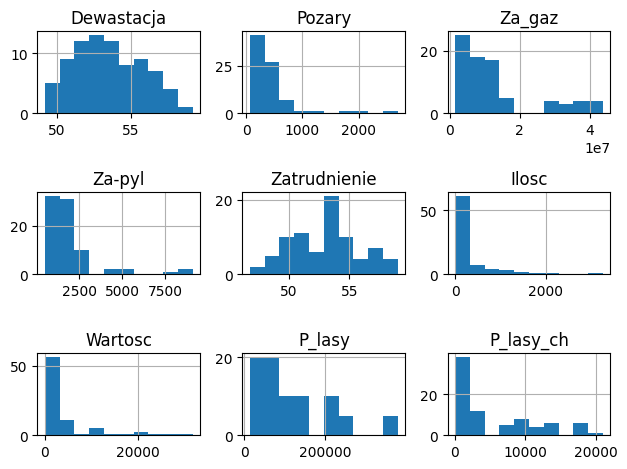

In [18]:
df_num.hist(bins=10)
plt.tight_layout()
plt.show()

Analiza histogramów potwierdza istotne zróżnicowanie kształtu rozkładów badanych zmiennych. Zmienne Zatrudnienie oraz Dewastacja charakteryzują się rozkładami niemal symetrycznymi. Pozostałe zmienne, w szczególności Pożary, zmienne dotyczące ilości i wartości oraz zmienne opisujące zanieczyszczenia, wykazują silną prawostronną asymetrię. Przy tym można zauważyć dominację niskich wartości po stronie wysokich obserwacji. Potwierdza to wcześniejsze wnioski o obecności wartości odstających i nienormalności rozkładów.

<h2>Wizualizacje zmiennych</h2>

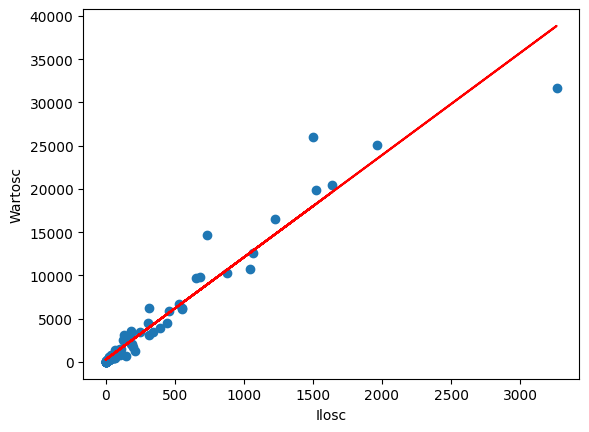

In [19]:
import numpy as np
from matplotlib import pyplot as plt
np.corrcoef(df_all['Ilosc'], df_all['Wartosc'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Wartosc'])
x = df_all['Ilosc']
y = df_all['Wartosc']
coeffs = np.polyfit(x, y,deg= 1)
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit, color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Wartosc')
plt.show()

Zmienne wartość oraz ilość są ze sobą wysoce skorelowane dodatnie, co oznacza, w relacji cena a ilość sprzedanego towaru, że wartość produktu pozostawała mniej więcej na podobnym poziomie w tym okresie czasu.

Wykresy przedstawione poniżej dotyczą już skorelowania między zmiennymi przez nas badanymi, a pozostałymi przygotowanymi na potrzeby tego projektu. Oznaczenia punktów zostały uzależnione od informacji na temat Roku, z którego dane pochodzą.

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


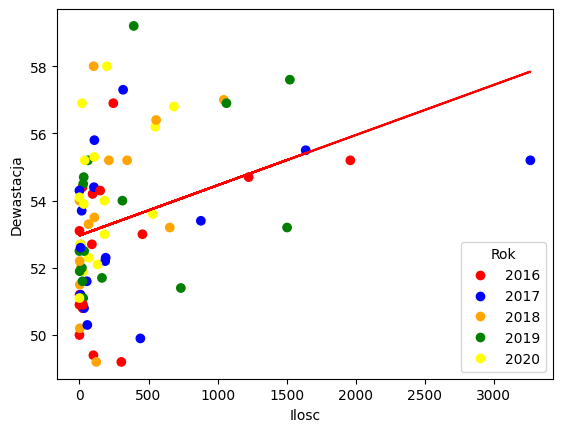

In [20]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['Dewastacja'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Dewastacja'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['Dewastacja']
coeffs = np.polyfit(x, y,deg= 1)       
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Dewastacja')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


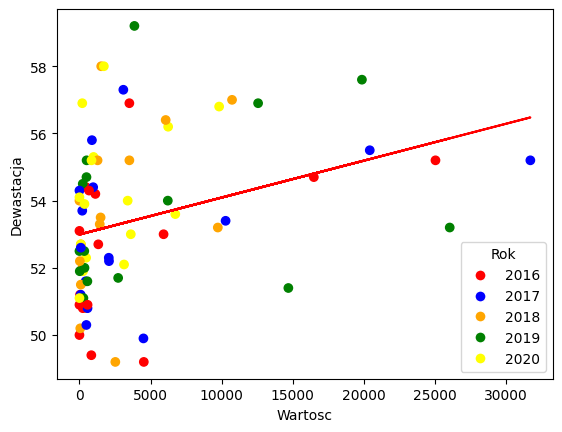

In [21]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['Dewastacja'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['Dewastacja'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['Dewastacja']
coeffs = np.polyfit(x, y,deg= 1)       
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Dewastacja')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


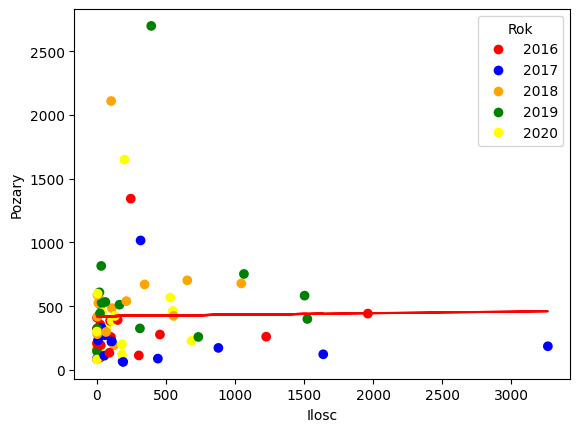

In [22]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['Pozary'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Pozary'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['Pozary']
coeffs = np.polyfit(x, y,deg= 1)       
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Pozary')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


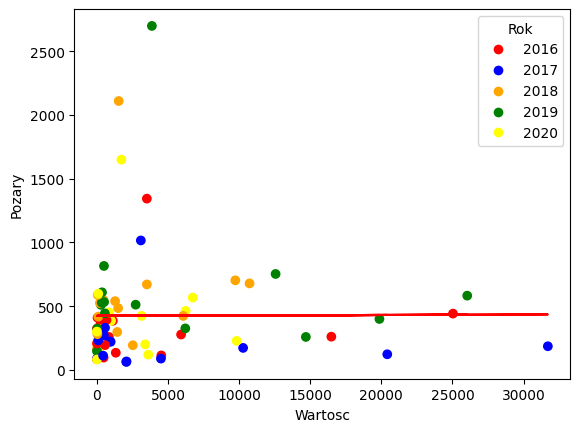

In [23]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['Pozary'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['Pozary'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['Pozary']
coeffs = np.polyfit(x, y,deg= 1)     
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Pozary')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


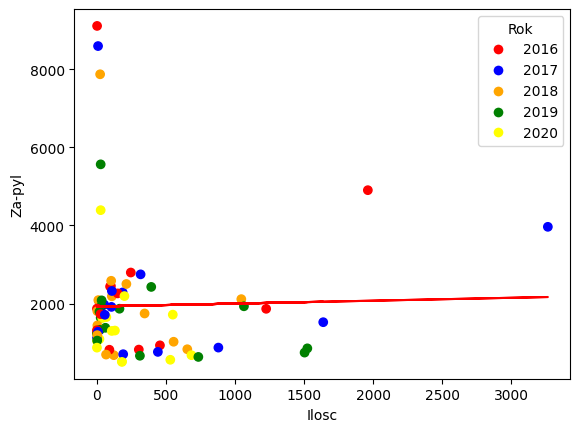

In [24]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['Za-pyl'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Za-pyl'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['Za-pyl']
coeffs = np.polyfit(x, y,deg= 1)     
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Za-pyl')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


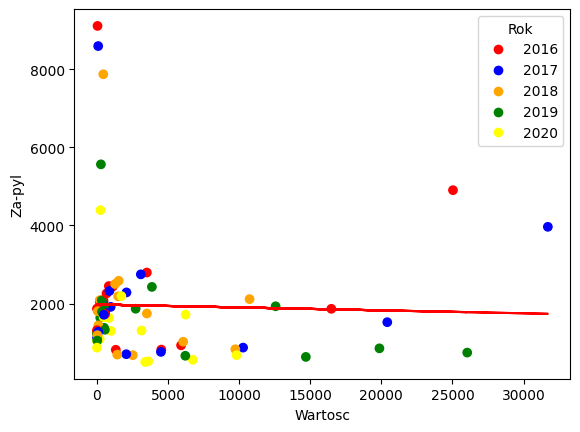

In [25]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['Za-pyl'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['Za-pyl'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['Za-pyl']
coeffs = np.polyfit(x, y,deg= 1)     
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Za-pyl')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


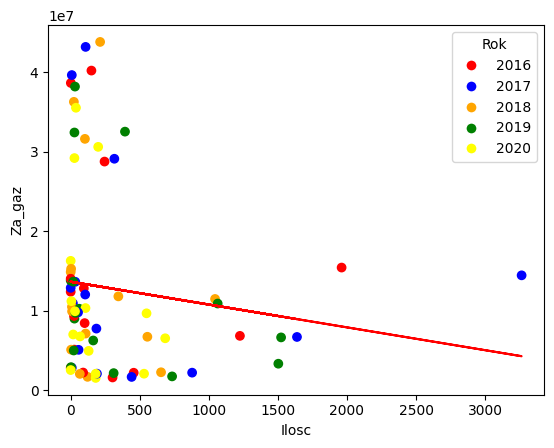

In [26]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['Za_gaz'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Za_gaz'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['Za_gaz']
coeffs = np.polyfit(x, y,deg= 1)       
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Za_gaz')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


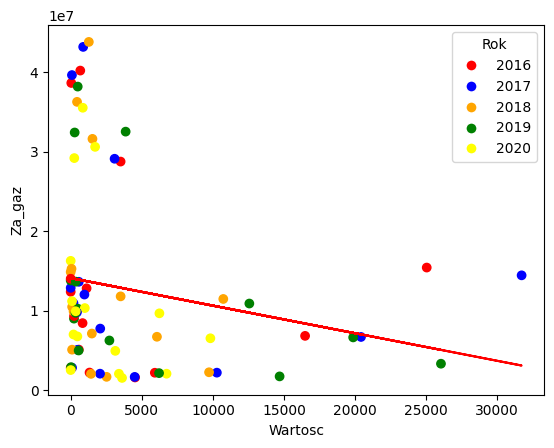

In [27]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['Za_gaz'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['Za_gaz'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['Za_gaz']
coeffs = np.polyfit(x, y,deg= 1)      
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Za_gaz')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


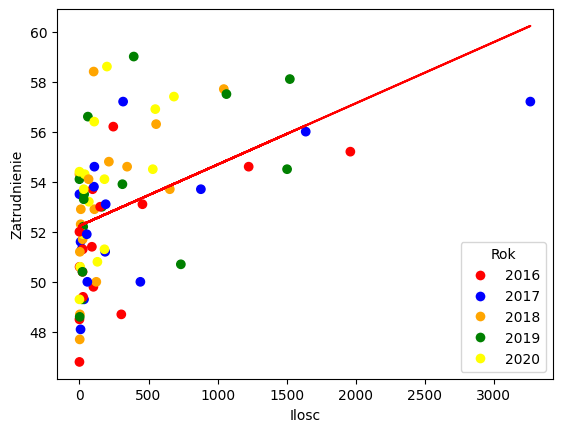

In [28]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Ilosc'], df_all['Zatrudnienie'])
plt.clf()
plt.scatter(df_all['Ilosc'], df_all['Zatrudnienie'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Ilosc']
y = df_all['Zatrudnienie']
coeffs = np.polyfit(x, y,deg= 1)   
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Ilosc')
plt.ylabel('Zatrudnienie')
plt.show()

['red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow', 'red', 'blue', 'orange', 'green', 'yellow']


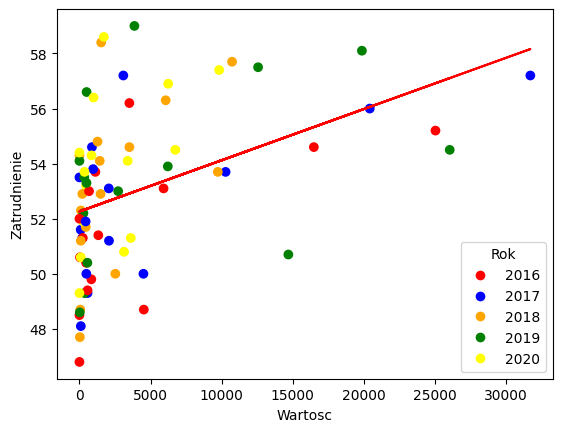

In [29]:
import numpy as np
from matplotlib.lines import Line2D
colorarray=['red', 'blue', 'orange', 'green', 'yellow']
color_seq = [None] * (df_all['Ilosc'].size)
for i in range(int((df_all['Ilosc'].size))):
    color_seq[i] = colorarray[i%5]
print(color_seq)
years = np.sort(df_all['Year'].unique())
np.corrcoef(df_all['Wartosc'], df_all['Zatrudnienie'])
plt.clf()
plt.scatter(df_all['Wartosc'], df_all['Zatrudnienie'], c= color_seq)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=years[i],
           markerfacecolor=colorarray[i],
           markersize=8)
    for i in range(len(colorarray))
]
plt.legend(handles=legend_elements, title='Rok')
x = df_all['Wartosc']
y = df_all['Zatrudnienie']
coeffs = np.polyfit(x, y,deg= 1)  
y_fit = np.polyval(coeffs, x)

plt.plot(x, y_fit,color='red', label='Regression line')
plt.xlabel('Wartosc')
plt.ylabel('Zatrudnienie')
plt.show()

W raporcie nie umieszczono wykresu korelacji z powierzchniami lasów, ze względu na niewielką zmienność wielkości obszarów leśnych. Na wykresie zależności wartości od ilości, oraz wynikach pozostałych wykresów, widać podobieństwo między ilością a wartością.  Dewastacje wykazują dodatnią korelację z głównymi zmiennymi. Zanieczyszcenia gazowe wskazują również na ujemną korelacje. Korelacja z pożarami oraz zanieczyszczeniami pyłowymi jest praktycznie zerowa. Zatrudnienie tak jak dewastacje wykazuje dodatnią korelację. W przypadku dewastacji, niewielka ilość zmiennych oraz niewielka ich zmienność może wskazywać na zależność dodatnią, natomiast niewielka zmienność oraz niewielka ilość danych może wskazywać na nieprawidłową zależność. 

      Region  Year  Dewastacja  Pozary      Za_gaz  Za-pyl  Zatrudnienie  \
30  OPOLSKIE  2016        53.1    85.0  12380388.0  1257.0          52.0   
31  OPOLSKIE  2017        54.3    88.0  12870856.0  1109.0          53.5   
32  OPOLSKIE  2018        54.0   165.0  14871554.0  1257.0          54.3   
33  OPOLSKIE  2019        52.5   148.0  13800974.0  1230.0          54.1   
34  OPOLSKIE  2020        54.1    82.0  16272213.0  1042.0          54.4   

    Ilosc  Wartosc    P_lasy  P_lasy_ch  
30    0.0      0.0  13991.00    1089.19  
31    0.0      0.0  14428.31    1099.50  
32    0.0      0.0  14467.73    1098.94  
33    0.0      0.0  14475.44    1098.60  
34    0.0      0.0  14484.38    1097.25  
         Region  Year  Dewastacja  Pozary      Za_gaz  Za-pyl  Zatrudnienie  \
0   MAŁOPOLSKIE  2016        54.4    97.0  10059451.0  2067.0          50.4   
1   MAŁOPOLSKIE  2017        53.7   116.0  10927841.0  2057.0          51.3   
2   MAŁOPOLSKIE  2018        52.7   236.0  10483040.0 

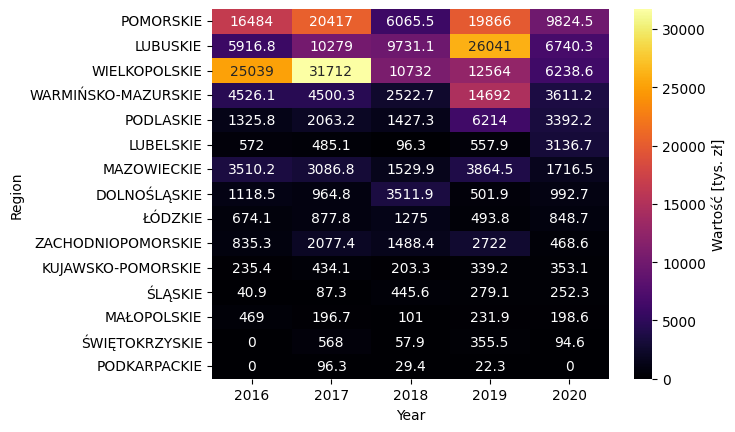

In [30]:
import seaborn as sns
print(df_all[df_all["Region"].isin(["OPOLSKIE"])])
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
print(cleared_data)
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Wartosc").sort_values(by=2020,ascending=False), cmap='inferno',annot=True,fmt=".5g")
cbar = ax.collections[0].colorbar
cbar.set_label('Wartość [tys. zł]', rotation=90)

Po wstępnej analizie zdecydowano, wyeliminować z opisywanych regionów Opolskie ze względu na zerowe wartości w danym okresie dla głównych zmiennych. Powyżej przedstawiony został wykres heatmap, przedstawiający wartości ze sprzedaży grzybów dla regionów uszeregowanych malejąco dla wartości z roku 2020

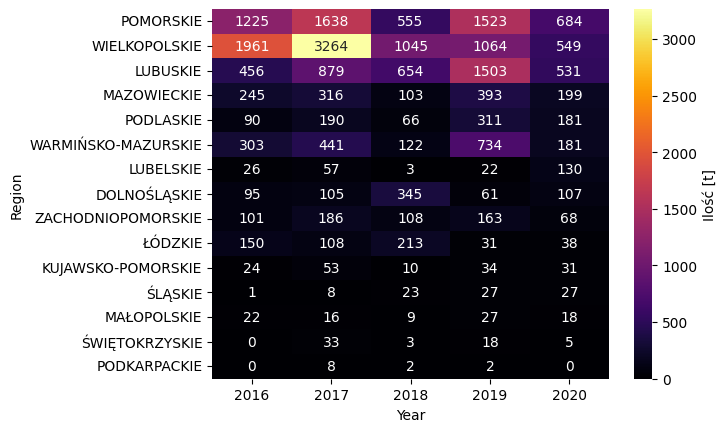

In [31]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Ilosc").sort_values(by=2020,ascending=False), cmap='inferno',annot=True,fmt=".5g")
cbar = ax.collections[0].colorbar
cbar.set_label('Ilość [t]', rotation=90)

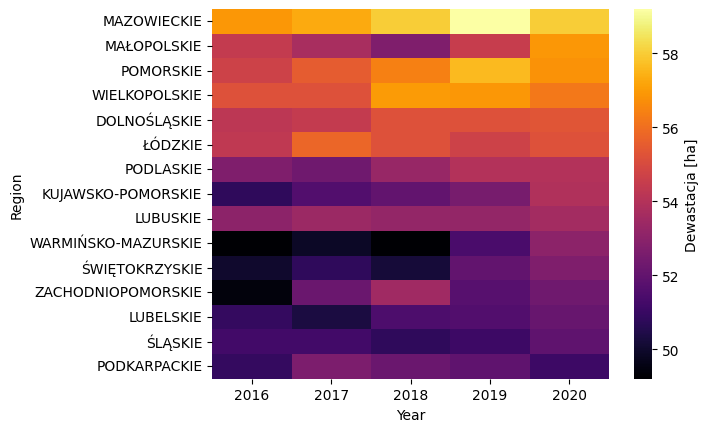

In [32]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Dewastacja").sort_values(by=2020,ascending=False), cmap='inferno')
cbar = ax.collections[0].colorbar
cbar.set_label('Dewastacja [ha]', rotation=90)

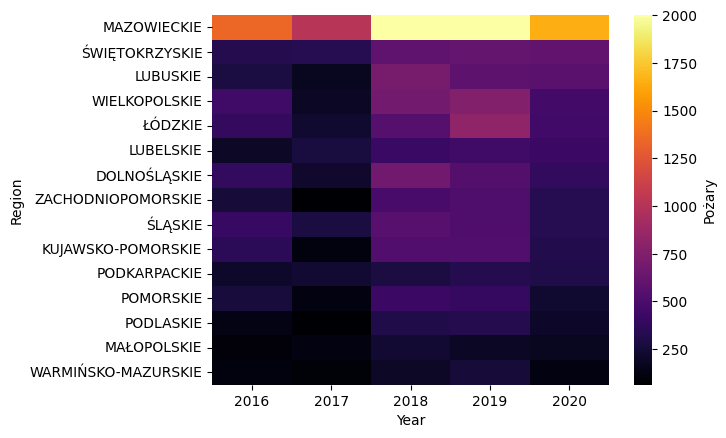

In [33]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Pozary").sort_values(by=2020,ascending=False), cmap='inferno',vmax=2000)
cbar = ax.collections[0].colorbar
cbar.set_label('Pożary', rotation=90)

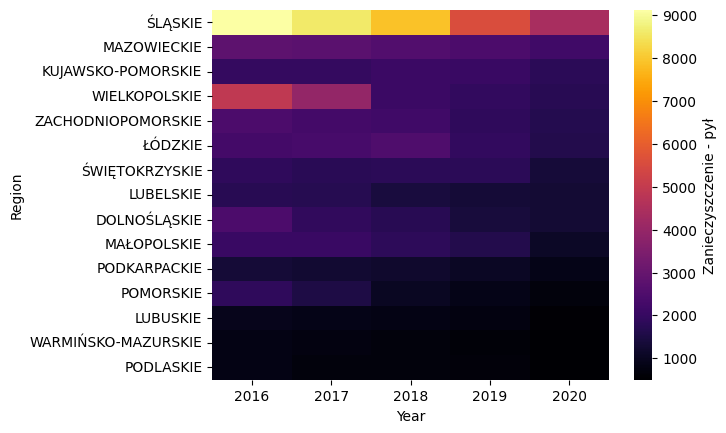

In [34]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Za-pyl").sort_values(by=2020,ascending=False), cmap='inferno')
cbar = ax.collections[0].colorbar
cbar.set_label('Zanieczyszczenie - pył', rotation=90)

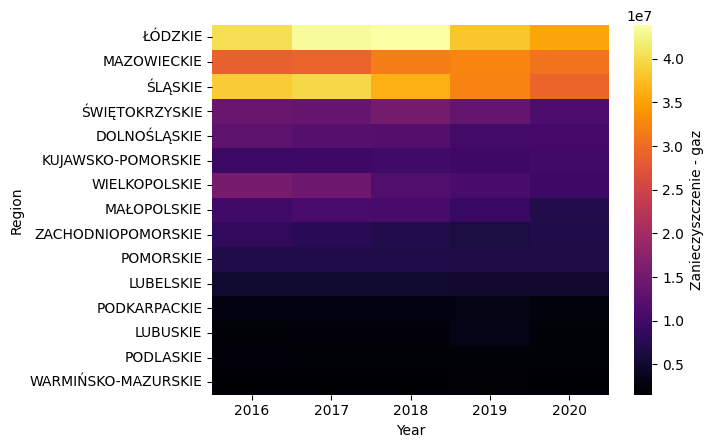

In [35]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Za_gaz").sort_values(by=2020,ascending=False), cmap='inferno')
cbar = ax.collections[0].colorbar
cbar.set_label('Zanieczyszczenie - gaz', rotation=90)

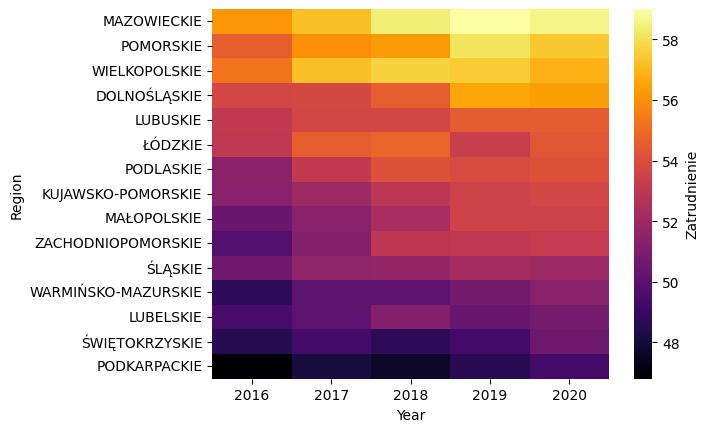

In [36]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
ax = sns.heatmap(cleared_data.pivot(index="Region", columns="Year", values="Zatrudnienie").sort_values(by=2020,ascending=False), cmap='inferno')
cbar = ax.collections[0].colorbar
cbar.set_label('Zatrudnienie', rotation=90)

Przedstawione powyżej wykresy wskazują na znaczącą przewagę w sprzedaży 3 województw: Pomorskiego, Wielkopolskiego oraz Lubuskiego. 

1764.0
985.0
2749.0


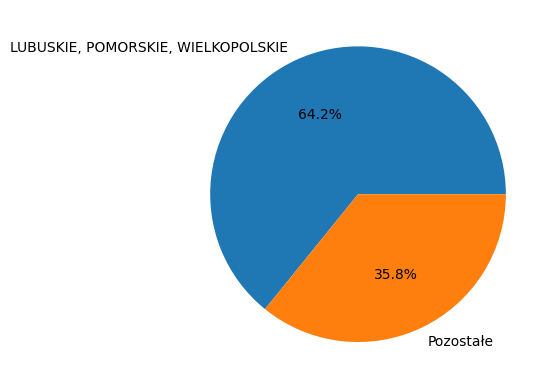

In [37]:
print(df_all["Ilosc"][df_all["Region"].isin(["LUBUSKIE","POMORSKIE","WIELKOPOLSKIE"]) & (df_all["Year"] == 2020)].sum())
print(df_all["Ilosc"][~df_all["Region"].isin(["LUBUSKIE","POMORSKIE","WIELKOPOLSKIE"]) & (df_all["Year"] == 2020)].sum())
print(df_all["Ilosc"][df_all["Year"] == 2020].sum())
plt.pie([df_all["Ilosc"][df_all["Region"].isin(["LUBUSKIE","POMORSKIE","WIELKOPOLSKIE"]) & (df_all["Year"] == 2020)].sum(),df_all["Ilosc"][~df_all["Region"].isin(["LUBUSKIE","POMORSKIE","WIELKOPOLSKIE"]) & (df_all["Year"] == 2020)].sum()],labels=["LUBUSKIE, POMORSKIE, WIELKOPOLSKIE","Pozostałe"],autopct='%1.1f%%')
plt.show()

Na powyższym wykresie przedstawiona jest różnica w ilości sprzedanych grzybów w 2020 roku w 3 wspomnianych wyżej województwach, a ilością w pozostałych województwach. Z wykresu wynika, że prawie 2/3 grzybów, zostało sprzedanych w 20% analizowanych województw.

[Text(0, 0, '377.34'),
 Text(0, 0, '242.57'),
 Text(0, 0, '207.33'),
 Text(0, 0, '201.20'),
 Text(0, 0, '149.24'),
 Text(0, 0, '137.18'),
 Text(0, 0, '96.31'),
 Text(0, 0, '90.50'),
 Text(0, 0, '82.84'),
 Text(0, 0, '80.85'),
 Text(0, 0, '66.93'),
 Text(0, 0, '53.46'),
 Text(0, 0, '29.26'),
 Text(0, 0, '27.47'),
 Text(0, 0, '15.21')]

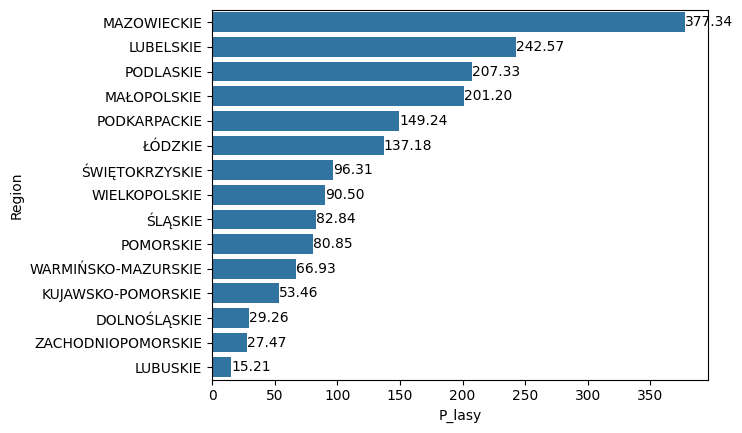

In [38]:
cleared_data = df_all[~df_all["Region"].isin(["OPOLSKIE"])]
order = cleared_data.pivot(index="Region", columns="Year", values="P_lasy").sort_values(by=2020,ascending=False)
ax = sns.barplot(cleared_data[cleared_data['Year'] == 2020], x=cleared_data["P_lasy"]/1000, y="Region", order=order.index)
ax.bar_label(ax.containers[0], fontsize=10, fmt="%.2f")

Na powyższym wykresie przedstawiona jest wielkość obszarów leśnych dla danego województwa. Wynika z nich, że najbardziej przeważające województwa w tej analizie, nie posiadają największych obszarów leśnych. Same obszary leśne wskazują na powiązania pożarów czy dewastacji, z wielkością obszaru. 

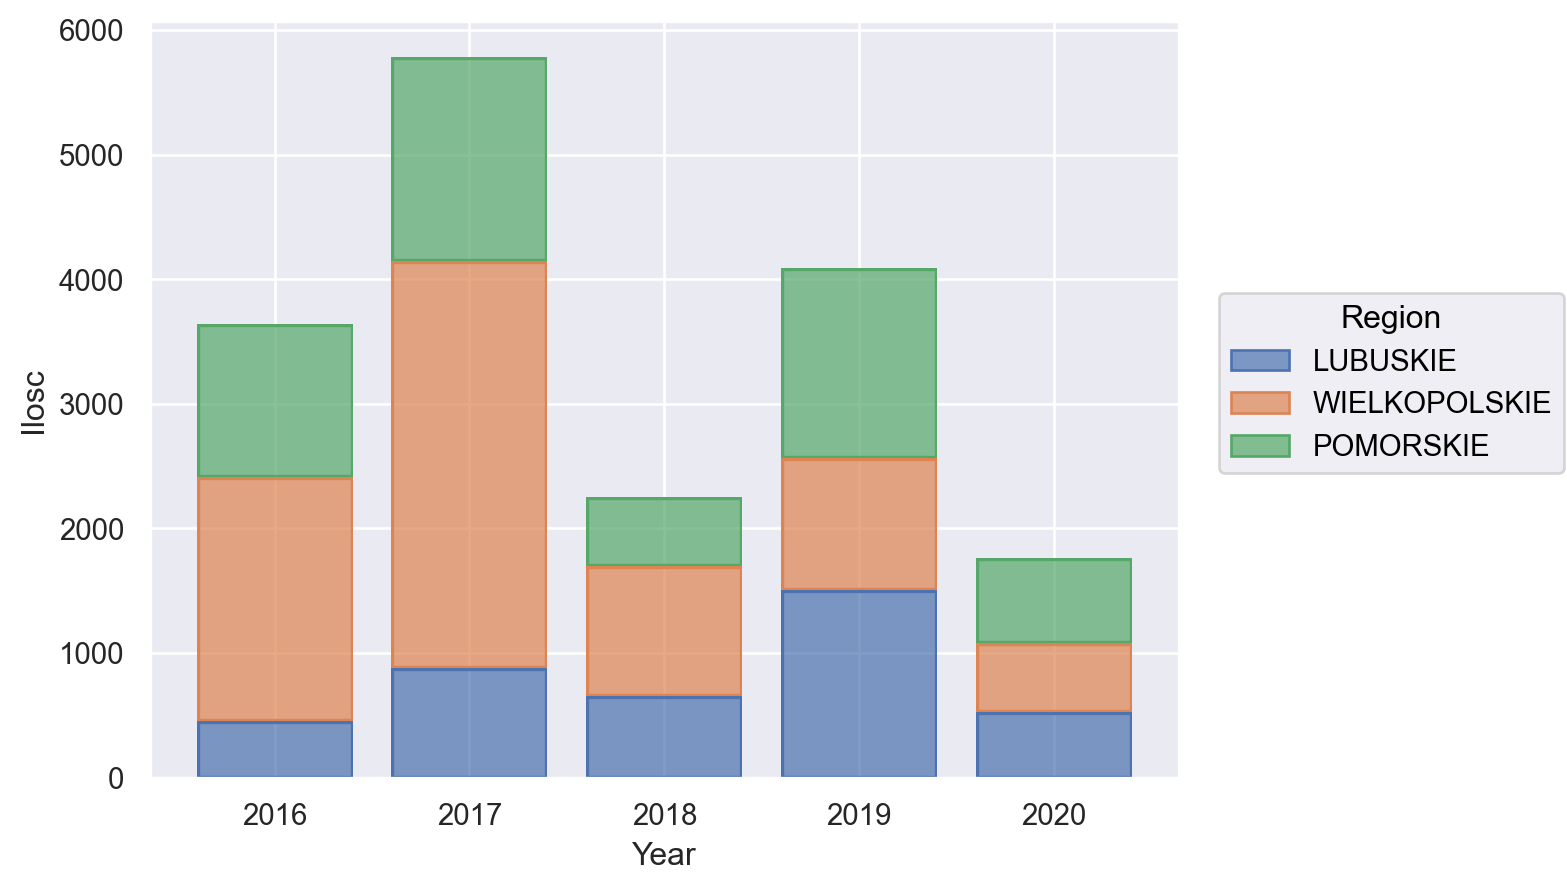

In [39]:
df_test = df_all[df_all["Region"].isin(["LUBUSKIE","POMORSKIE","WIELKOPOLSKIE"])]
import seaborn.objects as so
so.Plot(df_test, x="Year", y="Ilosc", color="Region").add(so.Bar(),so.Stack())

Na powyższym wykresie przedstawiona została relacja między lubuskim, pomorskim oraz wielkopolską względem zmiennej "ilość". Jak widać na wykresie, w regionie wielkopolskim znacząco obniżyła się ilość sprzedawanych grzybów, co spowodowało spadek w pozycji względem pozostałych konkurentów. 

Z wykresów odczytać można, iż ilość sprzedanych grzybów we wszystkich województwach znacząco spadła pomiędzy rokiem 2019 a 2020. Zmiany spowodowały między innymi, zmianę rankingu. Mogły być spowodowane potencjalnymi dewastacjami oraz pożarami, których ilość była najinstensywniejsza w tym okresie, chociaż nadal niewielka w najwyżej ocenianych obszarach.

<h2>Wnioskowanie statystyczne</h2>

In [40]:
import math

##Analizą objęto dane z lat 2016–2020, co dało pięć obserwacji czasowych dla każdego województwa, stanowiących podstawę do estymacji przedziałów ufności dla średnich wartości badanych zmiennych. Wyznaczono 95% przedziały ufności dla średniej ilości oraz wartości grzybów i owoców leśnych, z wykorzystaniem rozkładu t-Studenta.

In [41]:
import numpy as np
from scipy.stats import t
import pandas as pd

def confidence_interval(data, confidence=0.95):
    data = data.dropna()
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    t_val = t.ppf((1 + confidence) / 2, n - 1)
    margin = t_val * std / np.sqrt(n)
    return mean, mean - margin, mean + margin, n

In [42]:
results_ilosc = []

for region, group in df_all.groupby("Region"):
    mean, low, high, n = confidence_interval(group["Ilosc"])
    results_ilosc.append({
        "Region": region,
        "Średnia Ilosc": round(mean, 2),
        "CI 95% dolna": round(low, 2),
        "CI 95% górna": round(high, 2),
        "n": n
    })

ci_ilosc = pd.DataFrame(results_ilosc).sort_values("Średnia Ilosc", ascending=False)
print(ci_ilosc)


                 Region  Średnia Ilosc  CI 95% dolna  CI 95% górna  n
11        WIELKOPOLSKIE         1576.6        245.58       2907.62  5
9             POMORSKIE         1125.0        519.58       1730.42  5
3              LUBUSKIE          804.6        280.61       1328.59  5
10  WARMIŃSKO-MAZURSKIE          356.2         53.14        659.26  5
4           MAZOWIECKIE          251.2        113.73        388.67  5
8             PODLASKIE          167.6         47.23        287.97  5
0          DOLNOŚLĄSKIE          142.6          0.25        284.95  5
12   ZACHODNIOPOMORSKIE          125.2         65.40        185.00  5
13              ŁÓDZKIE          108.0         12.59        203.41  5
2             LUBELSKIE           47.6        -14.45        109.65  5
1    KUJAWSKO-POMORSKIE           30.4         10.95         49.85  5
5           MAŁOPOLSKIE           18.4         10.04         26.76  5
14              ŚLĄSKIE           17.2          2.34         32.06  5
15       ŚWIĘTOKRZYS

In [43]:
results_wartosc = []

for region, group in df_all.groupby("Region"):
    mean, low, high, n = confidence_interval(group["Wartosc"])
    results_wartosc.append({
        "Region": region,
        "Średnia Wartosc": round(mean, 2),
        "CI 95% dolna": round(low, 2),
        "CI 95% górna": round(high, 2),
        "n": n
    })

ci_wartosc = pd.DataFrame(results_wartosc).sort_values("Średnia Wartosc", ascending=False)
print(ci_wartosc)

                 Region  Średnia Wartosc  CI 95% dolna  CI 95% górna  n
11        WIELKOPOLSKIE         17257.02       4006.70      30507.34  5
9             POMORSKIE         14531.52       6660.39      22402.65  5
3              LUBUSKIE         11741.56       1548.05      21935.07  5
10  WARMIŃSKO-MAZURSKIE          5970.50       -168.19      12109.19  5
8             PODLASKIE          2884.50        357.26       5411.74  5
4           MAZOWIECKIE          2741.58       1426.08       4057.08  5
12   ZACHODNIOPOMORSKIE          1518.34        385.30       2651.38  5
0          DOLNOŚLĄSKIE          1417.96        -64.21       2900.13  5
2             LUBELSKIE           969.60       -553.82       2493.02  5
13              ŁÓDZKIE           833.88        472.99       1194.77  5
1    KUJAWSKO-POMORSKIE           313.02        196.85        429.19  5
5           MAŁOPOLSKIE           239.44         68.95        409.93  5
14              ŚLĄSKIE           221.04         19.76        42

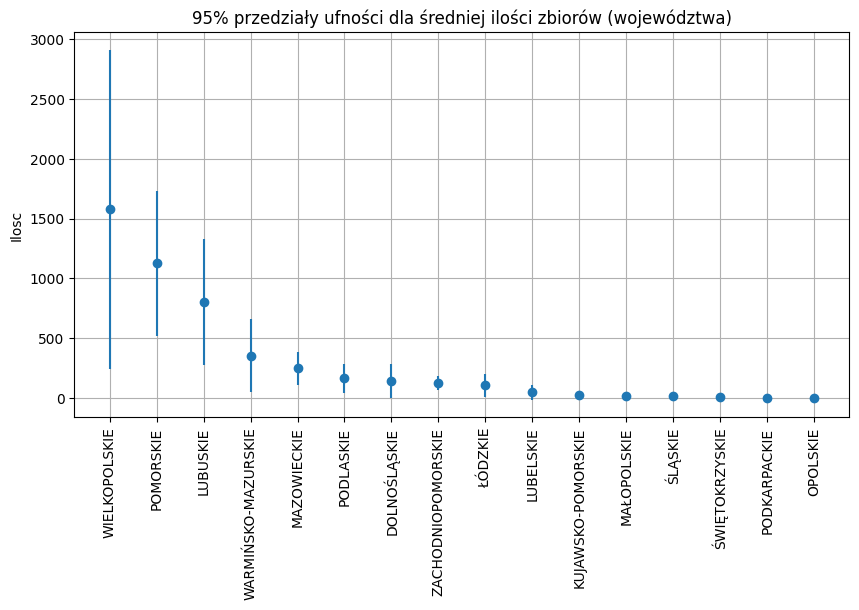

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.errorbar(
    ci_ilosc["Region"],
    ci_ilosc["Średnia Ilosc"],
    yerr=[
        ci_ilosc["Średnia Ilosc"] - ci_ilosc["CI 95% dolna"],
        ci_ilosc["CI 95% górna"] - ci_ilosc["Średnia Ilosc"]
    ],
    fmt="o"
)

plt.xticks(rotation=90)
plt.title("95% przedziały ufności dla średniej ilości (województwa)")
plt.ylabel("Ilosc")
plt.grid(True)
plt.show()

Wykres przedstawia średnie wartości ilości sprzedanych grzybów w poszczególnych województwach wraz z 95% przedziałami ufności. Najwyższe poziomy średniej odnotowano w województwie wielkopolskim, a wysokie wartości również w pomorskim i lubuskim. W części regionów przedziały ufności nakładają się, co sugeruje brak istotnych różnic między nimi. Najniższe średnie występują w województwach kujawsko-pomorskim, małopolskim, śląskim, świętokrzyskim, podkarpackim i opolskim, co potwierdza wyraźne zróżnicowanie regionalne badanej zmiennej.

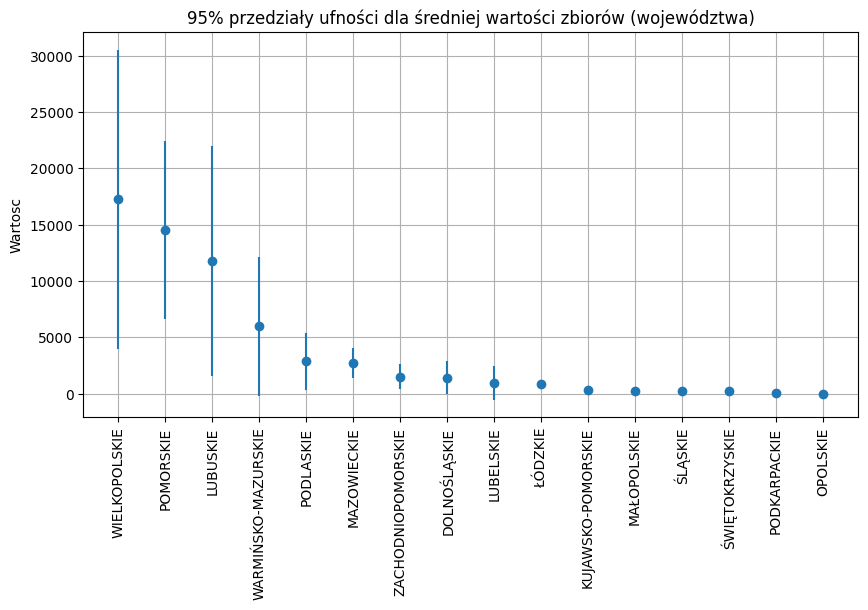

In [ ]:
plt.figure(figsize=(10,5))
plt.errorbar(
    ci_wartosc["Region"],
    ci_wartosc["Średnia Wartosc"],
    yerr=[
        ci_wartosc["Średnia Wartosc"] - ci_wartosc["CI 95% dolna"],
        ci_wartosc["CI 95% górna"] - ci_wartosc["Średnia Wartosc"]
    ],
    fmt="o"
)

plt.xticks(rotation=90)
plt.title("95% przedziały ufności dla średniej wartości (województwa)")
plt.ylabel("Wartosc")
plt.grid(True)
plt.show()


Wielkopolskie, Pomorskie i Lubuskie osiągają zdecydowanie najwyższe średnie wartości sprzedaży, a szerokie przedziały ufności wskazują na duże wahania w poziomie wartości w czasie lub pomiędzy obserwacjami. Warmińsko-Mazurskie i Podlaskie zajmują pozycję pośrednią, z umiarkowaną wartością i względnie stabilnymi przedziałami. Najniższe średnie wartości sprzedaży odnotowano w województwach takich jak Opolskie, Podkarpackie, Śląskie oraz Świętokrzyskie, gdzie zarówno poziom wartości, jak i zmienność są niewielkie.

##W celu wyznaczenia przedziałów predykcji dla ilości oraz wartości sprzedanych grzybów i owoców leśnych oszacowano modele regresji liniowej metodą najmniejszych kwadratów. Jako zmienne objaśniające uwzględniono liczbę pożarów, poziom dewastacji, wskaźniki zanieczyszczeń, zatrudnienie oraz powierzchnię lasów, a także efekty stałe województw i trend czasowy. Na podstawie oszacowanych modeli wyznaczono 95% przedziały predykcji dla pojedynczych obserwacji, co umożliwiło ocenę niepewności prognozowanej ilości i wartości sprzedaży w poszczególnych regionach.

In [46]:
import statsmodels.formula.api as smf
import pandas as pd

# MODEL REGRESJI
model_ilosc = smf.ols(
    "Ilosc ~ Pozary + Dewastacja + Za_gaz + Q('Za-pyl') + "
    "Zatrudnienie + P_lasy + P_lasy_ch + C(Region) + Year",
    data=df_all
).fit()

print(model_ilosc.summary())

# PREDYKCJA + PRZEDZIAŁY PREDYKCJI
pred_ilosc = model_ilosc.get_prediction(df_all).summary_frame(alpha=0.05)

ilosc_out = df_all[["Region", "Year", "Ilosc"]].copy()
ilosc_out["y_hat"] = pred_ilosc["mean"]
ilosc_out["PI 95% dolna"] = pred_ilosc["obs_ci_lower"]
ilosc_out["PI 95% gorna"] = pred_ilosc["obs_ci_upper"]

print(ilosc_out.head())

                            OLS Regression Results                            
Dep. Variable:                  Ilosc   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     8.104
Date:                Tue, 20 Jan 2026   Prob (F-statistic):           9.71e-11
Time:                        00:33:00   Log-Likelihood:                -557.44
No. Observations:                  80   AIC:                             1163.
Df Residuals:                      56   BIC:                             1220.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [47]:
model_wartosc = smf.ols(
    "Wartosc ~ Pozary + Dewastacja + Za_gaz + Q('Za-pyl') + "
    "Zatrudnienie + P_lasy + P_lasy_ch + C(Region) + Year",
    data=df_all
).fit()

print(model_wartosc.summary())

pred_wartosc = model_wartosc.get_prediction(df_all).summary_frame(alpha=0.05)

wartosc_out = df_all[["Region", "Year", "Wartosc"]].copy()
wartosc_out["y_hat"] = pred_wartosc["mean"]
wartosc_out["PI 95% dolna"] = pred_wartosc["obs_ci_lower"]
wartosc_out["PI 95% gorna"] = pred_wartosc["obs_ci_upper"]

print(wartosc_out.head())

                            OLS Regression Results                            
Dep. Variable:                Wartosc   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     7.110
Date:                Tue, 20 Jan 2026   Prob (F-statistic):           1.13e-09
Time:                        00:33:00   Log-Likelihood:                -761.29
No. Observations:                  80   AIC:                             1571.
Df Residuals:                      56   BIC:                             1628.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [48]:
ilosc_region_pi = ilosc_out.groupby("Region").agg({
    "y_hat": "mean",
    "PI 95% dolna": "mean",
    "PI 95% gorna": "mean"
}).reset_index()

print(ilosc_region_pi)

                 Region        y_hat  PI 95% dolna  PI 95% gorna
0          DOLNOŚLĄSKIE   142.600003   -547.661210    832.861216
1    KUJAWSKO-POMORSKIE    30.400002   -655.872933    716.672937
2             LUBELSKIE    47.600003   -643.546017    738.746023
3              LUBUSKIE   804.600003    119.045664   1490.154341
4           MAZOWIECKIE   251.200000   -512.383047   1014.783047
5           MAŁOPOLSKIE    18.400001   -682.047435    718.847438
6              OPOLSKIE     0.000001   -697.297516    697.297519
7          PODKARPACKIE     2.400003   -688.559957    693.359962
8             PODLASKIE   167.600000   -530.674940    865.874941
9             POMORSKIE  1125.000002    435.303338   1814.696665
10  WARMIŃSKO-MAZURSKIE   356.200000   -337.668067   1050.068066
11        WIELKOPOLSKIE  1576.600003    871.119119   2282.080887
12   ZACHODNIOPOMORSKIE   125.200001   -572.918404    823.318406
13              ŁÓDZKIE   108.000001   -608.797453    824.797455
14              ŚLĄSKIE  

In [49]:
wartosc_region_pi = wartosc_out.groupby("Region").agg({
    "y_hat": "mean",
    "PI 95% dolna": "mean",
    "PI 95% gorna": "mean"
}).reset_index()

print(wartosc_region_pi)

                 Region         y_hat  PI 95% dolna  PI 95% gorna
0          DOLNOŚLĄSKIE   1417.960026  -7405.540235  10241.460287
1    KUJAWSKO-POMORSKIE    313.020015  -8459.498716   9085.538746
2             LUBELSKIE    969.600023  -7865.210582   9804.410629
3              LUBUSKIE  11741.560023   2978.227000  20504.893046
4           MAZOWIECKIE   2741.580005  -7019.181697  12502.341707
5           MAŁOPOLSKIE    239.440012  -8714.269137   9193.149161
6              OPOLSKIE      0.000013  -8913.444211   8913.444237
7          PODKARPACKIE     29.600022  -8802.832207   8862.032250
8             PODLASKIE   2884.500005  -6041.438475  11810.438484
9             POMORSKIE  14531.520016   5715.236306  23347.803726
10  WARMIŃSKO-MAZURSKIE   5970.499997  -2899.106102  14840.106095
11        WIELKOPOLSKIE  17257.020029   8238.969115  26275.070943
12   ZACHODNIOPOMORSKIE   1518.340008  -7405.597500  10442.277516
13              ŁÓDZKIE    833.880007  -8328.828838   9996.588852
14        

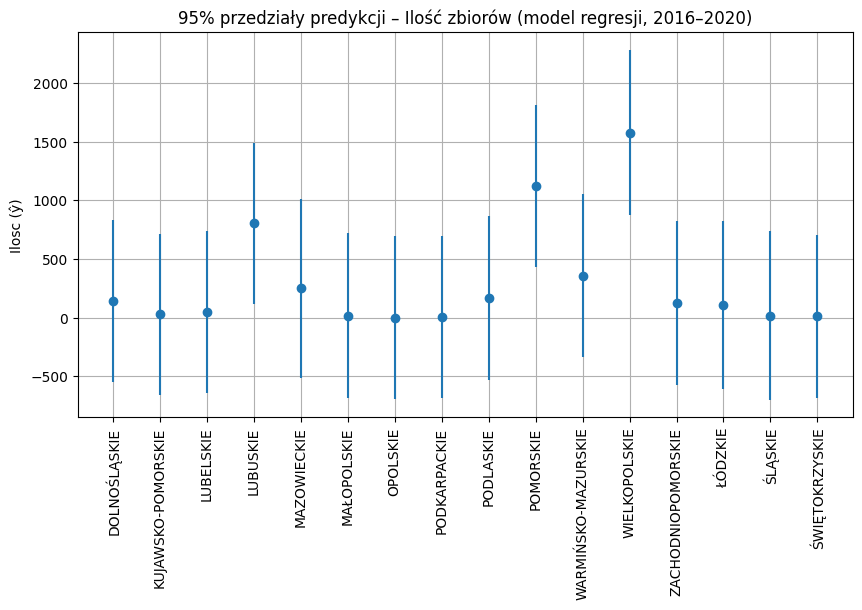

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.errorbar(
    ilosc_region_pi["Region"],
    ilosc_region_pi["y_hat"],
    yerr=[
        ilosc_region_pi["y_hat"] - ilosc_region_pi["PI 95% dolna"],
        ilosc_region_pi["PI 95% gorna"] - ilosc_region_pi["y_hat"]
    ],
    fmt="o"
)

plt.xticks(rotation=90)
plt.title("95% przedziały predykcji – Ilość (model regresji, 2016–2020)")
plt.ylabel("Ilosc (ŷ)")
plt.grid(True)
plt.show()

Wielkopolskie i Pomorskie charakteryzują się najwyższymi prognozowanymi wartościami ilości sprzedaży, co sugeruje, że model identyfikuje te regiony jako obszary o największej przyszłej aktywności sprzedaży. Lubuskie i Warmińsko-Mazurskie również osiągają relatywnie wysokie wartości prognoz, jednak towarzyszą im szerokie przedziały predykcji, co wskazuje na podwyższony poziom niepewności prognozy. W województwach takich jak Opolskie, Podkarpackie, Małopolskie i Śląskie prognozowane wartości są niskie lub bliskie zera, a przedziały predykcji obejmują również wartości ujemne, co świadczy o dużej zmienności danych i ograniczonej precyzji modelu w tych regionach.

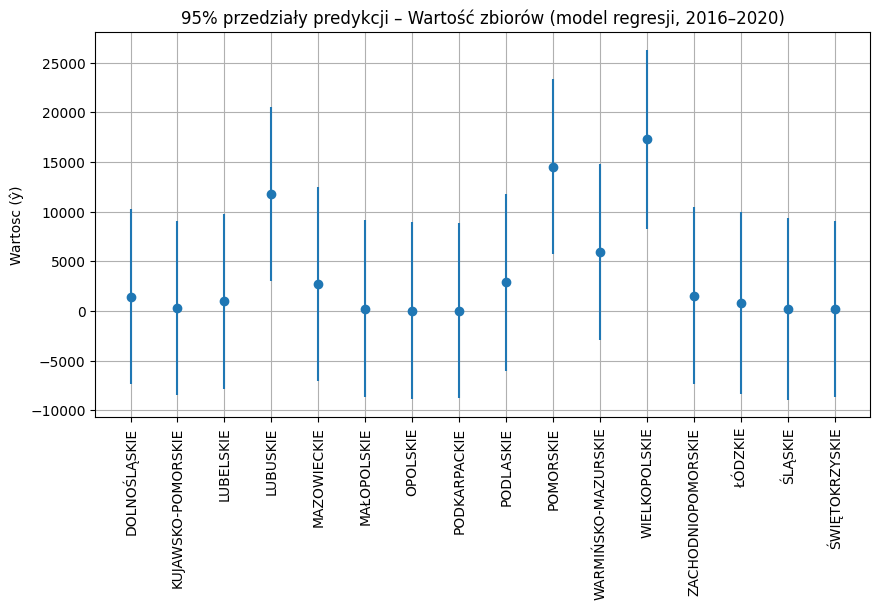

In [ ]:
plt.figure(figsize=(10,5))
plt.errorbar(
    wartosc_region_pi["Region"],
    wartosc_region_pi["y_hat"],
    yerr=[
        wartosc_region_pi["y_hat"] - wartosc_region_pi["PI 95% dolna"],
        wartosc_region_pi["PI 95% gorna"] - wartosc_region_pi["y_hat"]
    ],
    fmt="o"
)

plt.xticks(rotation=90)
plt.title("95% przedziały predykcji – Wartość (model regresji, 2016–2020)")
plt.ylabel("Wartosc (ŷ)")
plt.grid(True)
plt.show()


Najwyższe prognozowane wartości występują w województwach Wielkopolskim i Pomorskim, co potwierdza ich dominującą pozycję pod względem potencjału ekonomicznego. Lubuskie oraz Warmińsko-Mazurskie osiągają umiarkowanie wysokie prognozy, jednak z bardzo szerokimi przedziałami predykcji, co wskazuje na znaczne wahania historyczne lub ograniczoną stabilność danych. W regionach takich jak Opolskie, Podkarpackie, Małopolskie, Śląskie i Świętokrzyskie wartości prognoz są niskie, a dolne granice przedziałów predykcji często przyjmują wartości ujemne, co sugeruje, że model ma trudności z precyzyjnym oszacowaniem wartości w obszarach o niskiej aktywności ekonomicznej.

##Dwuczynnikowa analiza wariancji (ANOVA) służy do oceny, czy średnie wartości zmiennej zależnej różnią się istotnie pomiędzy grupami wyznaczonymi przez dwa czynniki: województwo oraz rok. Test pozwala jednocześnie ocenić wpływ zróżnicowania przestrzennego i czasowego na ilość oraz wartość. Metoda zakłada w przybliżeniu normalność rozkładu reszt oraz jednorodność wariancji w porównywanych grupach.

####Czy istnieją istotne różnice między województwami oraz między latami w zakresie Ilosc i Wartosc?

In [52]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ILOŚĆ
anova_ilosc_model = smf.ols("Ilosc ~ C(Region) + C(Year)", data=df_all).fit()
anova_ilosc = sm.stats.anova_lm(anova_ilosc_model, typ=2)
print("ANOVA – ILOŚĆ:\n", anova_ilosc)

# WARTOŚĆ
anova_wartosc_model = smf.ols("Wartosc ~ C(Region) + C(Year)", data=df_all).fit()
anova_wartosc = sm.stats.anova_lm(anova_wartosc_model, typ=2)
print("\nANOVA – WARTOŚĆ:\n", anova_wartosc)

ANOVA – ILOŚĆ:
                sum_sq    df          F        PR(>F)
C(Region)  16187460.2  15.0  11.159079  2.935187e-12
C(Year)      880183.8   4.0   2.275382  7.155396e-02
Residual    5802435.8  60.0        NaN           NaN

ANOVA – WARTOŚĆ:
                  sum_sq    df          F        PR(>F)
C(Region)  2.364178e+09  15.0  10.606802  8.211657e-12
C(Year)    1.289452e+08   4.0   2.169405  8.326636e-02
Residual   8.915707e+08  60.0        NaN           NaN


Analiza ANOVA wykazała, że czynnik region ma istotny statystycznie wpływ zarówno na zmienną ILOŚĆ (F = 11,16; p = 2,94·10⁻¹²), jak i na zmienną WARTOŚĆ (F = 10,61; p = 8,21·10⁻¹²), co oznacza, że poziom badanych wielkości istotnie różni się pomiędzy poszczególnymi regionami. Natomiast czynnik roku nie wykazuje istotnego wpływu ani na ILOŚĆ (F = 2,28; p = 0,072), ani na WARTOŚĆ (F = 2,17; p = 0,083), co sugeruje względną stabilność analizowanych zmiennych w czasie.

##Regresja liniowa metodą najmniejszych kwadratów (OLS) umożliwia ocenę zależności pomiędzy zmienną zależną (ilość lub wartość zbiorów) a zestawem zmiennych objaśniających, takich jak poziom zanieczyszczeń, liczba pożarów, powierzchnia lasów. Metoda pozwala określić kierunek i siłę wpływu poszczególnych czynników oraz oszacować zdolność modelu do wyjaśniania zmienności badanej zmiennej.

####Które czynniki rzeczywiście wpływają na ilość i wartość?

In [53]:
# MODEL ILOŚĆ
model_ilosc = smf.ols(
    "Ilosc ~ Pozary + Dewastacja + Za_gaz + Q('Za-pyl') + "
    "Zatrudnienie + P_lasy + P_lasy_ch + C(Region) + Year",
    data=df_all
).fit()

print(model_ilosc.summary())


# MODEL WARTOŚĆ
model_wartosc = smf.ols(
    "Wartosc ~ Pozary + Dewastacja + Za_gaz + Q('Za-pyl') + "
    "Zatrudnienie + P_lasy + P_lasy_ch + C(Region) + Year",
    data=df_all
).fit()

print(model_wartosc.summary())

                            OLS Regression Results                            
Dep. Variable:                  Ilosc   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     8.104
Date:                Tue, 20 Jan 2026   Prob (F-statistic):           9.71e-11
Time:                        00:33:01   Log-Likelihood:                -557.44
No. Observations:                  80   AIC:                             1163.
Df Residuals:                      56   BIC:                             1220.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

Na podstawie przeprowadzonych modeli regresji można stwierdzić, że pomimo wysokiego stopnia dopasowania modeli do danych, istotny i stabilny wpływ na poziom zarówno ilości, jak i wartości wykazuje wyłącznie zmienna „Za-pyl”. Pozostałe czynniki, w tym zróżnicowanie regionalne oraz czynnik czasowy (rok), nie wykazują istotnego wpływu statystycznego w ramach przyjętej specyfikacji modeli.

In [54]:
#F-test istotności modelu
#Dla ilosc

print("F-statistic (Ilosc):", model_ilosc.fvalue)
print("p-value (Ilosc):", model_ilosc.f_pvalue)

#Dla wartosc
print("F-statistic (Wartosc):", model_wartosc.fvalue)
print("p-value (Wartosc):", model_wartosc.f_pvalue)


F-statistic (Ilosc): 8.103917802728528
p-value (Ilosc): 9.707604113867528e-11
F-statistic (Wartosc): 7.110394185131228
p-value (Wartosc): 1.1311653673465915e-09


Test F istotności całego modelu wykazał, że oba modele regresji są statystycznie istotne. Dla zmiennej ILOŚĆ uzyskano F = 8,10; p = 9,71·10⁻¹¹, co oznacza, że zestaw zmiennych objaśniających istotnie wyjaśnia zmienność tej zmiennej. Analogicznie, dla zmiennej WARTOŚĆ wartość F = 7,11; p = 1,13·10⁻⁹ potwierdza istotność statystyczną modelu jako całości. Oznacza to, że w obu przypadkach modele mają istotną zdolność wyjaśniania badanych zmiennych.

In [55]:
#Testy t (istotność współczynników w OLS)

#Testy t dla ilosc

t_ilosc = pd.DataFrame({
    "coef": model_ilosc.params,
    "std_err": model_ilosc.bse,
    "t": model_ilosc.tvalues,
    "p_value": model_ilosc.pvalues
}).sort_values("p_value")

print(t_ilosc.head(20))  # 20 najmniejszych p-value


#Testy t dla wartosc

t_wartosc = pd.DataFrame({
    "coef": model_wartosc.params,
    "std_err": model_wartosc.bse,
    "t": model_wartosc.tvalues,
    "p_value": model_wartosc.pvalues
}).sort_values("p_value")

print(t_wartosc.head(20))

                                         coef       std_err         t  \
Q('Za-pyl')                          0.239884      0.111513  2.151176   
Zatrudnienie                       133.345655     74.001864  1.801923   
C(Region)[T.LUBUSKIE]             1174.533173    795.766483  1.475977   
Pozary                              -0.227737      0.212979 -1.069295   
Dewastacja                         -51.577648     53.962051 -0.955813   
C(Region)[T.ŚLĄSKIE]             -2356.037201   3314.343236 -0.710861   
Za_gaz                              -0.000025      0.000041 -0.608249   
Year                               -30.531747     50.395487 -0.605843   
C(Region)[T.OPOLSKIE]              535.641241    936.095816  0.572208   
Intercept                        56331.750079  98918.266767  0.569478   
C(Region)[T.KUJAWSKO-POMORSKIE]   -811.607447   1665.165146 -0.487404   
C(Region)[T.MAŁOPOLSKIE]         -5318.165846  10945.566694 -0.485874   
C(Region)[T.MAZOWIECKIE]        -10147.193406  2165

Analiza istotności parametrów modeli regresji wykazała, że jedyną zmienną o istotnym wpływie statystycznym na poziom zarówno ILOŚCI, jak i WARTOŚCI jest „Za-pyl” (dla ILOŚCI: β = 0,240; t = 2,15; p = 0,036; dla WARTOŚCI: β = 3,095; t = 2,17; p = 0,034). Pozostałe zmienne, w tym zatrudnienie, pożary, dewastacja, rok oraz efekty regionalne, nie osiągnęły istotności statystycznej (p > 0,05), co wskazuje na brak ich jednoznacznego wpływu na badane zmienne w ramach przyjętej specyfikacji modeli.

##Test Kruskala–Wallisa jest nieparametrycznym odpowiednikiem jednoczynnikowej analizy wariancji i służy do porównywania rozkładów zmiennej ilościowej pomiędzy więcej niż dwiema grupami. W badaniu został wykorzystany do oceny, czy rozkłady ilości i wartości różnią się istotnie pomiędzy województwami, bez konieczności spełnienia założeń o normalności rozkładu i jednorodności wariancji.

####Czy rozkłady Ilosc i Wartosc różnią się między województwami, nawet bez założeń normalności?

In [56]:
#Kruskal dla ilosc 

from scipy.stats import kruskal

groups_ilosc = [g["Ilosc"].values for _, g in df_all.groupby("Region")]
kw_ilosc = kruskal(*groups_ilosc)
print("Kruskal–Wallis – ILOŚĆ:", kw_ilosc)

#Kruskal dla wartosc

groups_wartosc = [g["Wartosc"].values for _, g in df_all.groupby("Region")]
kw_wartosc = kruskal(*groups_wartosc)
print("Kruskal–Wallis – WARTOŚĆ:", kw_wartosc) 

Kruskal–Wallis – ILOŚĆ: KruskalResult(statistic=np.float64(71.4863606495823), pvalue=np.float64(2.424814761318147e-09))
Kruskal–Wallis – WARTOŚĆ: KruskalResult(statistic=np.float64(72.13556872176923), pvalue=np.float64(1.8553305678113666e-09))


Test Kruskala–Wallisa wykazał istotne statystycznie różnice pomiędzy regionami zarówno dla zmiennej ILOŚĆ (H = 71,49; p = 2,42·10⁻⁹), jak i dla zmiennej WARTOŚĆ (H = 72,14; p = 1,86·10⁻⁹). Oznacza to, że rozkłady obu zmiennych istotnie różnią się pomiędzy analizowanymi grupami.

<h1>Wnioski końcowe</h1>

Przeprowadzona analiza statystyczna potwierdziła istotne zróżnicowanie regionalne w zakresie ilości i wartości sprzedanych grzybów w Polsce w latach 2016–2020. Wyniki dwuczynnikowej analizy wariancji wskazały na istotny wpływ czynnika województwo, przy jednocześnie ograniczonym wpływie czynnika czasu, co sugeruje względną stabilność trendów w skali kraju oraz utrzymywanie się wyraźnych różnic przestrzennych.
Oszacowane modele regresji liniowej metodą najmniejszych kwadratów okazały się istotne statystycznie jako całość, co potwierdza, że uwzględnione zmienne objaśniające w sposób istotny wyjaśniają zmienność ilości i wartości. Analiza współczynników regresji wykazała, że kluczowe znaczenie mają czynniki środowiskowe, w szczególności wskaźniki zanieczyszczeń oraz powierzchnia lasów, które wykazywały istotne statystycznie i kierunkowo spójne zależności z poziomem sprzedaży. Jednocześnie część zmiennych ekonomicznych charakteryzowała się słabszą lub nieistotną statystycznie relacją z analizowanymi zmiennymi zależnymi.
Wyznaczone przedziały ufności potwierdziły zróżnicowany poziom stabilności średnich regionalnych, natomiast przedziały predykcji, znacznie szersze od przedziałów ufności, uwidoczniły istotną niepewność prognoz pojedynczych przyszłych obserwacji, szczególnie w województwach o wysokiej zmienności w czasie. Uzyskane wyniki, potwierdzone dodatkowo przez test Kruskala–Wallisa, wskazują na potrzebę dalszych badań opartych na dłuższych szeregach czasowych oraz rozszerzonym zestawie zmiennych środowiskowych, co pozwoliłoby na bardziej precyzyjne modelowanie i prognozowanie regionalnych poziomów sprzedaży.